# 🏗️ Webinar 2 – Tu Primer Modelo Completo
**Curso de Data Science & Machine Learning**  
Dataset: Online Retail (ventas de e-commerce)

---

## ¿Qué vamos a construir hoy?

| Parte | Pregunta de negocio | Tipo de modelo |
|---|---|---|
| 🔵 Parte 1 | ¿Es este cliente de *alto valor*? | **Clasificación** |
| 🟠 Parte 2 | ¿Cuánto va a gastar este cliente? | **Regresión** |

> 💡 **Regla de oro que nunca vas a olvidar:**  
> El modelo **nunca debe ver los datos de test** durante el entrenamiento.

---
## 0. Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split  #ayuda a dividir los datos en entrenamiento y prueba

# Clasificación
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)  #funcion para evaluar diferentes métricas 

# Regresión
from sklearn.linear_model import LinearRegression #Importamos el modelo de regresión lineal
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Librerías cargadas')

✅ Librerías cargadas


In [ ]:
df = pd.read_excel('../Webinar 1 Teoría/online_retail.xlsx', nrows=30000)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    30000 non-null  object        
 1   StockCode    30000 non-null  object        
 2   Description  29886 non-null  str           
 3   Quantity     30000 non-null  int64         
 4   InvoiceDate  30000 non-null  datetime64[us]
 5   UnitPrice    30000 non-null  float64       
 6   CustomerID   19957 non-null  float64       
 7   Country      30000 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(2)
memory usage: 1.8+ MB


In [25]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,30000.000000,30000,30000.000000,19957.000000
mean,7.511900,2010-12-07 11:13:35.569999,6.609601,15577.340682
min,-9360.000000,2010-12-01 08:26:00,0.000000,12347.000000
25%,1.000000,2010-12-05 10:45:00,1.280000,14298.000000
50%,2.000000,2010-12-07 15:03:00,2.510000,15574.000000
75%,6.000000,2010-12-09 20:01:00,4.250000,17211.000000
max,2880.000000,2010-12-14 13:10:00,13541.330000,18269.000000
std,65.558646,NaN,165.555161,1738.577043


**OJO**:
* Hay muchos ID que son ausentes, como tengo que organizar x venta x ususario, tendremos que eliminarlos
* En quantity tenemos un minimo de -9360, debe de ser una devolución o un error, hay que limpiar
* El precio tambien tiene oportunidades, ya que hay un precio minimo de 0.

In [20]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [51]:
#Total gastado x compra
df['TotalSpent'] = df['Quantity'] * df['UnitPrice']

#Agrupar x cliente
clientes = df.groupby('CustomerID').agg({
    'TotalSpent': 'sum',
    'Country': 'first',
    'Quantity': 'count'}).reset_index()

#Definir que es un cliente de alto valor
#un cliente de alto valor es aquel que compra por arriba de la mediana
media = clientes['TotalSpent'].median()
clientes['AltoValor'] = (clientes['TotalSpent'] > media).astype(int)  #recuerda que con ASTYPE puedes convertir booleanos a enteros (1 y 0)


print(f' Dataset listo: {clientes.shape[0]} clientes únicos')
clientes.head()



 Dataset listo: 755 clientes únicos


,CustomerID,TotalSpent,Country,Quantity,AltoValor
0,12347.0,711.79,Iceland,31,1
1,12370.0,1590.82,Cyprus,83,1
2,12386.0,258.90,Australia,8,0
3,12395.0,346.10,Belgium,12,1
4,12427.0,303.50,Germany,10,1


In [48]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalSpent
count,30000.000000,30000,30000.000000,19957.000000,30000.000000
mean,7.511900,2010-12-07 11:13:35.569999,6.609601,15577.340682,16.759129
min,-9360.000000,2010-12-01 08:26:00,0.000000,12347.000000,-13541.330000
25%,1.000000,2010-12-05 10:45:00,1.280000,14298.000000,3.320000
50%,2.000000,2010-12-07 15:03:00,2.510000,15574.000000,7.950000
75%,6.000000,2010-12-09 20:01:00,4.250000,17211.000000,16.950000
max,2880.000000,2010-12-14 13:10:00,13541.330000,18269.000000,13541.330000
std,65.558646,NaN,165.555161,1738.577043,179.878633


In [ ]:
#Calcular el total gastado por cada compra
df["TotalSpent"] = df["Quantity"] * df["UnitPrice"]

#Agrupar por cliente por total gastado, cantidad de clientes y país
clientes = df.groupby("CustomerID").agg({
    "TotalSpent": "sum",
    "Quantity": "count", 
    "Country": "first"}).reset_index()



#Definir clientes de alto valor y frecuentes

media = clientes["TotalSpent"].median() #Calculamos que un cliente que es de alto valo es aquel que la mediana del total gastado es mayor a la mediana general. Es decir, que compra más que el cliente promedio.
clientes["AltoValor"]= (clientes["TotalSpent"] > media).astype(int) #OJO recuerda que tenemos que convertir la columna en 1 y 0's y para esto SIEMPRE se usa astype(int)
clientes["es_frecuente"] = (clientes["Quantity"] > 10).astype(int) #Definimos que un cliente es frecuente si ha hecho más de 10 compras

print(f'Dataset listo: {clientes.shape[0]} clientes únicos')
clientes.head()

Dataset listo: 755 clientes únicos


,CustomerID,TotalSpent,Quantity,Country,AltoValor,es_frecuente
0,12347.0,711.79,31,Iceland,1,1
1,12370.0,1590.82,83,Cyprus,1,1
2,12386.0,258.90,8,Australia,0,0
3,12395.0,346.10,12,Belgium,1,1
4,12427.0,303.50,10,Germany,1,0


---
# 🔵 PARTE 1 — Clasificación
## Pregunta: ¿Es este cliente de alto valor?

**Target:** `es_alto_valor` → `1` si gastó más que la mediana, `0` si no.

El flujo completo que vamos a seguir:

```
[1] Definir X e y  →  [2] Split  →  [3] Fit  →  [4] Predict  →  [5] Evaluar
```

### [1] Definir X (features) e y (target)

- **X** = las columnas que el modelo *puede usar* para aprender  
- **y** = lo que queremos *predecir*

> ¿Qué columnas tiene sentido usar para saber si un cliente es de alto valor?

In [55]:
# Definir X e y
#X = clientes[["TotalSpent", "Quantity"]] #Seleccionamos las columnas que son importantes para la predicción.
#Ojo !! la linea anterior NO es correcta porq TOTAL SPENT depende de la columna de Alto Valor y eso es lo que queremos predecir, por lo tanto, no podemos usar esa columna como variable independiente.
X = clientes[["Quantity", "es_frecuente"]] #Seleccionamos las columnas q no dependen de la columna de Alto Valor, es decir, las que no son el gasto total por cliente, sino la cantidad de compras y si es frecuente o no.
y = clientes["AltoValor"] #Seleccionamos la columna que queremos predecir


print('Shape de X:', X.shape) #Verificamos que X tenga el número correcto de filas y columnas
print()
print('Distribución del target y:') 
print(y.value_counts(normalize=True).round(2)) #Se revisa q tan balanceado esta el modelo, es decir, cuántos clientes de alto valor y no alto valor tenemos en el dataset

Shape de X: (755, 2)

Distribución del target y:
AltoValor
0    0.5
1    0.5
Name: proportion, dtype: float64


### [2] Split — separar train y test

**¿Por qué no entrenamos con todo el dataset?**  
Necesitamos un conjunto que el modelo **nunca haya visto** para saber si realmente aprendió, o solo memorizó.

```
Dataset completo
│
├── 80% → X_train, y_train  ← el modelo aprende aquí
└── 20% → X_test,  y_test   ← solo para evaluar al final
```

In [56]:
# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 42, stratify = y) #Se divide el dataset en train para entrenar y test para evaluar. 
#Siempre se coloca el X, Y, el tamaño del test (q siempre es del 20%) y el random state de 42 para que la división sea siempre la misma cada vez que se ejecute el código. 
#El stratify solo se usa cuando los datos estan desbalanceados, es decir, cuando hay muchos más clientes de alto valor que no alto valor o viceversa. Esto ayuda a que la división sea representativa de ambas clases.

print(f'Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X):.0%})')
print(f'Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(X):.0%})')

Train: 604 filas (80%)
Test:  151 filas  (20%)


### [3] Fit — el modelo aprende

Usamos **Regresión Logística**: a pesar del nombre, es un modelo de *clasificación*.  
Aprende una frontera que separa clase 0 de clase 1.

> `.fit()` es donde ocurre todo el aprendizaje. Solo usamos `X_train`.

In [57]:
#Ajustar el modelo a los datos de entrenamiento
model = LogisticRegression(random_state=42) #Creamos una instancia del modelo de regresión logística
model.fit(X_train, y_train) #Entrenamos el modelo con los datos de entrenamiento

print('✅ Modelo entrenado')

✅ Modelo entrenado


### [4] Predict — el modelo predice

Ahora le pasamos los datos de test que **nunca vio**.  
Hay dos tipos de predicción:
- `.predict()` → clase directa: `0` o `1`
- `.predict_proba()` → probabilidad de cada clase: `[0.3, 0.7]`

> ⚠️ Predecimos tanto en **train** como en **test** para poder comparar.

In [58]:
#Predecir en train y en test para comparar con los valores reales y evaluar el desempeño del modelo
predicciones_train = model.predict(X_train) #Hacemos predicciones con el modelo entrenado en los datos de entrenamiento
predicciones_test = model.predict(X_test) #Hacemos predicciones con el modelo entrenado en los datos de prueba

print('Primeras 5 — train:')
print('  Predicciones:', predicciones_train[:5])
print('  Reales:      ', y_train.values[:5])
print()
print('Primeras 5 — test:')
print('  Predicciones:', predicciones_test[:5])
print('  Reales:      ', y_test.values[:5])

Primeras 5 — train:
  Predicciones: [1 0 1 0 0]
  Reales:       [0 0 1 0 0]

Primeras 5 — test:
  Predicciones: [1 0 0 1 0]
  Reales:       [0 0 0 1 0]


### [5] Evaluar — ¿qué tan bien lo hizo?

#### Matriz de Confusión — entender los errores

```
                  Predijo: NO    Predijo: SÍ
Real: NO    →     TN  ✅          FP  ❌
Real: SÍ    →     FN  ❌          TP  ✅
```

Mostramos **train y test lado a lado** para detectar si hay un problema de bias o variance:
- Si **train es bueno, test es malo** → **overfitting** (alta variance)
- Si **ambos son malos** → **underfitting** (alto bias)

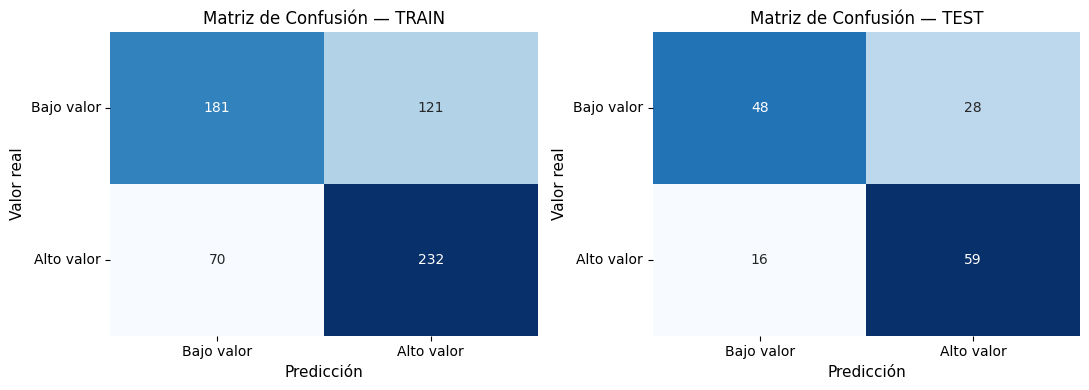

In [59]:
# Evaluar el desempeño del modelo con una matriz de confusión

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_true, y_pred, titulo in [
    (axes[0], y_train, predicciones_train, 'Matriz de Confusión — TRAIN'),
    (axes[1], y_test,  predicciones_test,  'Matriz de Confusión — TEST'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Valor real', fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.set_xticklabels(['Bajo valor', 'Alto valor'])
    ax.set_yticklabels(['Bajo valor', 'Alto valor'], rotation=0)

plt.tight_layout()
plt.show()

#OJO RECUERDA QUE LA MATRIZ IDEAL ES LA QUE TIENE LOS NUMEROS DE LA DIAGONAL DE FALSOS NEGATIVOS Y FALSOS POSITIVOS EN CERO.
#Entonces estas matrices de confusión. Usualmente. Lo que me ayudan es para ver qué tan bien le está yendo al modelo para detectar los verdaderos positivos y los verdaderos negativos. Es decir, que también un modelo está clasificando, lo que debe clasificar. 


#### Las 4 métricas con sklearn

| Métrica | Pregunta que responde |
|---|---|
| **Accuracy**  | ¿Qué % acerté en total? |
| **Precision** | De los que predije como SÍ, ¿cuántos eran SÍ? |
| **Recall**    | De todos los SÍ reales, ¿cuántos encontré? |
| **F1**        | Balance entre Precision y Recall |

Comparamos **train vs test** para detectar bias/variance.

In [60]:
# definir las métricas a calcular y mostrar en pantalla
def metricas(y_true, y_pred, conjunto):
    print(f'Métricas de desempeño — {conjunto}')
    print('  Accuracy:  ', accuracy_score(y_true, y_pred))
    print('  Precision: ', precision_score(y_true, y_pred))
    print('  Recall:    ', recall_score(y_true, y_pred))
    print('  F1-score:  ', f1_score(y_true, y_pred))
    print()


metricas(y_train, predicciones_train, 'TRAIN')
metricas(y_test,  predicciones_test,  'TEST')

Métricas de desempeño — TRAIN
  Accuracy:   0.6837748344370861
  Precision:  0.6572237960339944
  Recall:     0.7682119205298014
  F1-score:   0.7083969465648855

Métricas de desempeño — TEST
  Accuracy:   0.7086092715231788
  Precision:  0.6781609195402298
  Recall:     0.7866666666666666
  F1-score:   0.7283950617283951



#### Bonus: agregar una feature nueva y ver si mejora

¿Qué pasa si le damos al modelo el **gasto promedio por compra** como feature adicional?

In [63]:
clientes['gasto_promedio'] = clientes['TotalSpent'] / clientes['Quantity']

X2 = clientes[['Quantity', 'es_frecuente', 'gasto_promedio']]
y2 = clientes['AltoValor']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

m2 = LogisticRegression(random_state=42)
m2.fit(X2_train, y2_train)

preds2_train = m2.predict(X2_train)
preds2_test  = m2.predict(X2_test)

print('── Modelo ORIGINAL — TEST ──')
print(classification_report(y_test, predicciones_test, target_names=['Bajo valor', 'Alto valor'])) #Con classification report podemos ver TODAS las metricas 

print('── Modelo MEJORADO (+ gasto_promedio) — TEST ──')
print(classification_report(y2_test, preds2_test, target_names=['Bajo valor', 'Alto valor']))

── Modelo ORIGINAL — TEST ──
              precision    recall  f1-score   support

  Bajo valor       0.75      0.63      0.69        76
  Alto valor       0.68      0.79      0.73        75

    accuracy                           0.71       151
   macro avg       0.71      0.71      0.71       151
weighted avg       0.71      0.71      0.71       151

── Modelo MEJORADO (+ gasto_promedio) — TEST ──
              precision    recall  f1-score   support

  Bajo valor       0.86      0.74      0.79        73
  Alto valor       0.78      0.88      0.83        78

    accuracy                           0.81       151
   macro avg       0.82      0.81      0.81       151
weighted avg       0.82      0.81      0.81       151



---
# 🟠 PARTE 2 — Regresión
## Pregunta: ¿Cuánto va a gastar este cliente?

Ahora el target no es una **categoría** (0/1) sino un **número continuo**: `total_gastado`.

El flujo es **exactamente el mismo**, solo cambian:
- El modelo: `LinearRegression` en vez de `LogisticRegression`
- Las métricas: MAE, RMSE, R² en vez de precision/recall

### [1] Definir X e y

Ahora `y` es cuánto gastó el cliente — un valor numérico.

In [17]:
X_reg = clientes[['num_compras', 'es_frecuente']]
y_reg = clientes['total_gastado']

print('Shape de X:', X_reg.shape)
print()
print('Distribución del target (total_gastado):')
print(y_reg.describe().round(2))

KeyError: "['num_compras'] not in index"

### [2] Split

In [ ]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print(f'Train: {X_reg_train.shape[0]} filas')
print(f'Test:  {X_reg_test.shape[0]} filas')

Train: 604 filas
Test:  151 filas


### [3] Fit

In [ ]:
#Definir el modelo de regresión, ajustarlo a los datos de entrenamiento y mostrar los coeficientes aprendidos

print('✅ Modelo de regresión entrenado')
print()
print('Coeficientes aprendidos:')
for feature, coef in zip(X_reg.columns, modelo_reg.coef_):
    print(f'  {feature:>15}:  {coef:>8.2f}')
print(f'  {"intercepto":>15}:  {modelo_reg.intercept_:>8.2f}')

✅ Modelo de regresión entrenado

Coeficientes aprendidos:
      num_compras:      8.58
     es_frecuente:    218.57
       intercepto:    171.55


### [4] Predict

In [ ]:
pred_reg_train = modelo_reg.predict(X_reg_train)
pred_reg_test  = modelo_reg.predict(X_reg_test)

print('Primeras 5 predicciones — TEST (€ estimados):')
print(pred_reg_test[:5].round(2))
print()
print('Valores reales — TEST:')
print(y_reg_test.values[:5].round(2))

Primeras 5 predicciones — TEST (€ estimados):
[664.64 518.8  518.8  690.37 501.64]

Valores reales — TEST:
[257.22 273.29 706.27 620.43 248.1 ]


### [5] Evaluar — métricas de regresión

En regresión no hay "acertó o falló" — medimos **qué tan lejos** estuvo la predicción.

| Métrica | Qué mide |
|---|---|
| **MAE** | Error promedio en las mismas unidades que y |
| **RMSE** | Penaliza más los errores grandes |
| **R²** | % de varianza explicada (1.0 = perfecto, 0 = inútil) |

Comparamos **train vs test** para detectar bias/variance.

In [ ]:
def metricas_reg(y_true, y_pred, nombre):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'── {nombre} ──')
    print(f'  MAE:  {mae:>8.2f} €')
    print(f'  RMSE: {rmse:>8.2f} €')
    print(f'  R²:   {r2:>8.3f}   ({r2:.1%} de la varianza explicada)')
    print()

metricas_reg(y_reg_train, pred_reg_train, 'TRAIN')
metricas_reg(y_reg_test,  pred_reg_test,  'TEST')

── TRAIN ──
  MAE:    429.76 €
  RMSE:  1438.22 €
  R²:      0.058   (5.8% de la varianza explicada)

── TEST ──
  MAE:    360.26 €
  RMSE:   528.27 €
  R²:      0.396   (39.6% de la varianza explicada)



#### Visualizar: valores reales vs. predichos — Train y Test

Si el modelo fuera perfecto, **todos los puntos caerían sobre la línea roja**.  
Comparar los dos gráficos revela si hay overfitting.

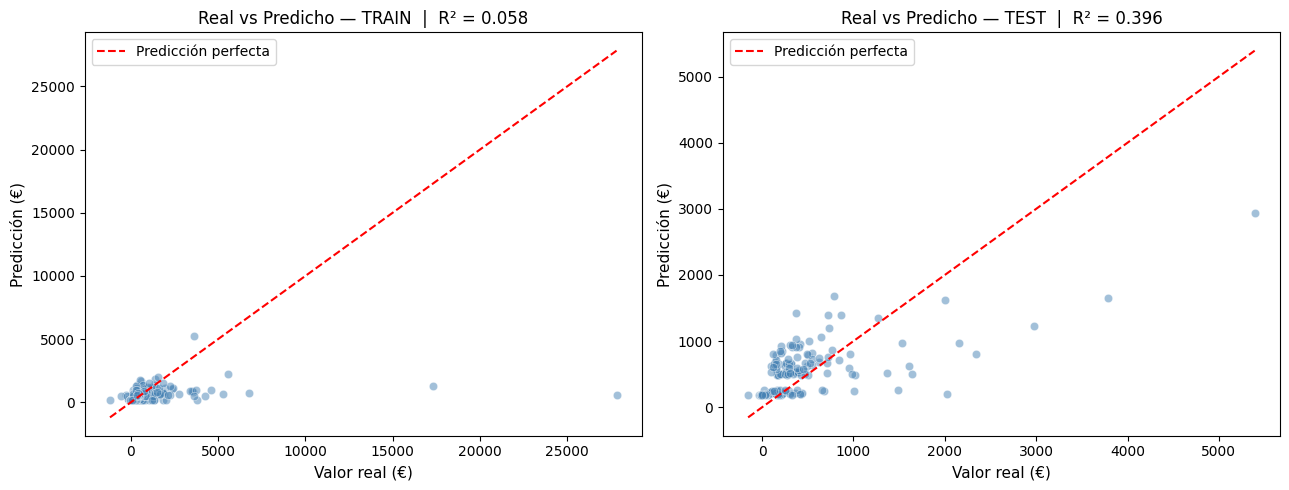

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, nombre in [
    (axes[0], y_reg_train, pred_reg_train, 'TRAIN'),
    (axes[1], y_reg_test,  pred_reg_test,  'TEST'),
]:
    r2 = r2_score(y_true, y_pred)
    ax.scatter(y_true, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Valor real (€)', fontsize=11)
    ax.set_ylabel('Predicción (€)', fontsize=11)
    ax.set_title(f'Real vs Predicho — {nombre}  |  R² = {r2:.3f}', fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

#### Bonus: agregar `gasto_promedio` también en regresión

¿Mejora el R² si usamos la misma feature nueva que en clasificación?

In [ ]:
X_reg2 = clientes[['num_compras', 'es_frecuente', 'gasto_promedio']]
y_reg2 = clientes['total_gastado']

X_r2_train, X_r2_test, y_r2_train, y_r2_test = train_test_split(X_reg2, y_reg2, test_size=0.2, random_state=42)

m_reg2 = LinearRegression()
m_reg2.fit(X_r2_train, y_r2_train)

pred_r2_train = m_reg2.predict(X_r2_train)
pred_r2_test  = m_reg2.predict(X_r2_test)

print('── Modelo ORIGINAL ──')
metricas_reg(y_reg_train, pred_reg_train, 'Train')
metricas_reg(y_reg_test,  pred_reg_test,  'Test')

print('── Modelo MEJORADO (+ gasto_promedio) ──')
metricas_reg(y_r2_train, pred_r2_train, 'Train')
metricas_reg(y_r2_test,  pred_r2_test,  'Test')

── Modelo ORIGINAL ──
── Train ──
  MAE:    429.76 €
  RMSE:  1438.22 €
  R²:      0.058   (5.8% de la varianza explicada)

── Test ──
  MAE:    360.26 €
  RMSE:   528.27 €
  R²:      0.396   (39.6% de la varianza explicada)

── Modelo MEJORADO (+ gasto_promedio) ──
── Train ──
  MAE:    396.12 €
  RMSE:  1290.84 €
  R²:      0.241   (24.1% de la varianza explicada)

── Test ──
  MAE:    321.12 €
  RMSE:   468.83 €
  R²:      0.524   (52.4% de la varianza explicada)



---
## ✅ Resumen del Webinar 2

### El flujo es siempre el mismo
```
Datos → X e y → Split → Fit → Predict → Evaluar
```

### Lo que cambia según el tipo de problema

| | Clasificación | Regresión |
|---|---|---|
| **Target** | Categoría (0/1, A/B/C) | Número continuo |
| **Modelo** | `LogisticRegression` | `LinearRegression` |
| **Métricas** | Accuracy, Precision, Recall, F1 | MAE, RMSE, R² |
| **Primer vistazo** | `classification_report` | Gráfico Real vs Predicho |

### ¿Cómo detectar bias vs variance?

| Train | Test | Diagnóstico |
|---|---|---|
| ✅ Bueno | ✅ Bueno | Modelo correcto |
| ✅ Bueno | ❌ Malo | **Overfitting** (alta variance) |
| ❌ Malo | ❌ Malo | **Underfitting** (alto bias) |

### ¿Qué métrica usar en clasificación?

| Escenario | Métrica |
|---|---|
| FP son costosos (filtro de spam) | **Precision** |
| FN son costosos (detector de cáncer) | **Recall** |
| Ambos importan por igual | **F1 Score** |
| Dataset balanceado, costo simétrico | **Accuracy** |

---
**→ Webinar 3: más modelos (Decision Tree, Random Forest), hiperparámetros y cross-validation.**